In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
data = pd.read_csv(r'C:\Users\user\Downloads\train.csv')

EDA


In [4]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [10]:
data['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [11]:
data['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [12]:
data.isnull().sum() # check for missing values

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [13]:
data['Age'] = data.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))   
# fill missing values in 'Age' column with median age of each class and gender

In [14]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0]) # fill missing values in 'Embarked' column with mode

In [15]:
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

<Axes: xlabel='Fare'>

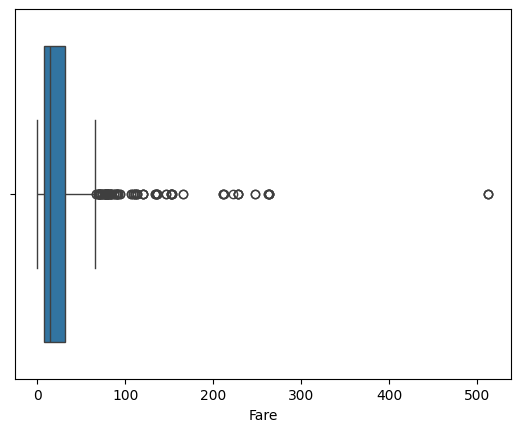

In [16]:
import seaborn as sns
sns.boxplot(x=data['Fare'])


<Axes: xlabel='Age'>

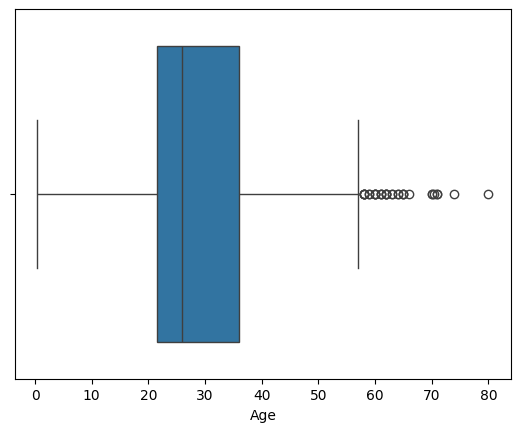

In [17]:
sns.boxplot(x=data['Age'])

In [18]:
data["Fare"] = np.log1p(data["Fare"]) # log transformation to reduce skewness of 'Fare' column

<Axes: xlabel='Fare'>

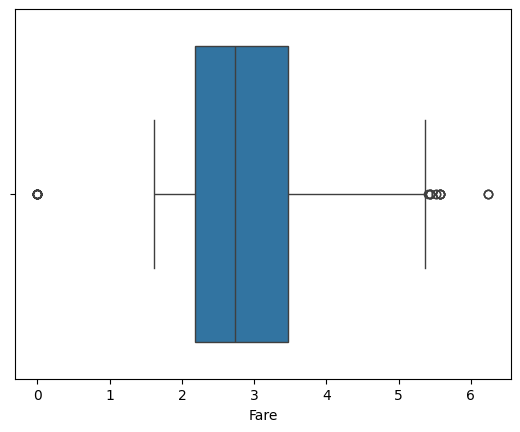

In [19]:
sns.boxplot(x=data['Fare'])


<Axes: xlabel='Fare', ylabel='Count'>

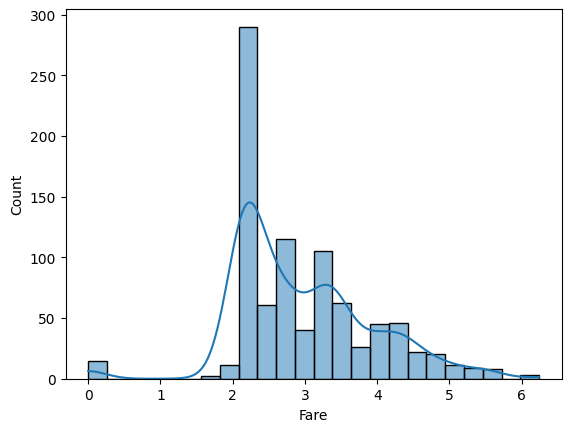

In [20]:
sns.histplot(data['Fare'], kde=True)

Feature Engineering

In [21]:
data["family"]=data["SibSp"] + data["Parch"]  + 1 # create new feature 'family' by adding 'SibSp' and 'Parch' columns


In [22]:
data["isAlone"] = data["family"].apply(lambda x: 1 if x == 1 else 0) # create new feature 'isAlone' to indicate if passenger is alone or not

In [23]:
r= data["isAlone"] .value_counts()

In [24]:
r/len(data['family']) * 100 # percentage of passengers who are alone vs with family

isAlone
1    60.26936
0    39.73064
Name: count, dtype: float64

In [25]:
data['AgeGroup'] = pd.cut(data['Age'], bins=[0,12,25,50,100], labels=['Child','Young','Adult','Senior'])

In [26]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,family,isAlone,AgeGroup
0,0,3,male,22.0,1,0,2.110213,S,2,0,Young
1,1,1,female,38.0,1,0,4.280593,C,2,0,Adult
2,1,3,female,26.0,0,0,2.188856,S,1,1,Adult
3,1,1,female,35.0,1,0,3.990834,S,2,0,Adult
4,0,3,male,35.0,0,0,2.202765,S,1,1,Adult


In [27]:
age_dummies = pd.get_dummies(data['AgeGroup'], prefix='AgeGroup')
data = pd.concat([data, age_dummies], axis=1)

In [28]:
embarked_dummies = pd.get_dummies(data['Embarked'], prefix='Embarked')
data = pd.concat([data, embarked_dummies], axis=1)

In [29]:
data['Sex'].unique()

array(['male', 'female'], dtype=object)

In [30]:
data['Sex'] = data['Sex'].map({'female':0, 'male':1})

In [31]:
data.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,family,isAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,29.112424,0.523008,0.381594,2.962246,1.904602,0.602694
std,0.486592,0.836071,0.477990,13.304424,1.102743,0.806057,0.969048,1.613459,0.489615
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,2.000000,0.000000,21.500000,0.000000,0.000000,2.187218,1.000000,0.000000
50%,0.000000,3.000000,1.000000,26.000000,0.000000,0.000000,2.737881,1.000000,1.000000
75%,1.000000,3.000000,1.000000,36.000000,1.000000,0.000000,3.465736,2.000000,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,6.240917,11.000000,1.000000


In [32]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,family,isAlone,AgeGroup,AgeGroup_Child,AgeGroup_Young,AgeGroup_Adult,AgeGroup_Senior,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,2.110213,S,2,0,Young,False,True,False,False,False,False,True
1,1,1,0,38.0,1,0,4.280593,C,2,0,Adult,False,False,True,False,True,False,False
2,1,3,0,26.0,0,0,2.188856,S,1,1,Adult,False,False,True,False,False,False,True
3,1,1,0,35.0,1,0,3.990834,S,2,0,Adult,False,False,True,False,False,False,True
4,0,3,1,35.0,0,0,2.202765,S,1,1,Adult,False,False,True,False,False,False,True


In [33]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'family', 'isAlone', 'AgeGroup', 'AgeGroup_Child',
       'AgeGroup_Young', 'AgeGroup_Adult', 'AgeGroup_Senior', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [34]:
data = data.loc[:, ~data.columns.duplicated()]
data.drop(['Embarked', 'AgeGroup'], axis=1, inplace=True)

In [35]:

data.columns


Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'family',
       'isAlone', 'AgeGroup_Child', 'AgeGroup_Young', 'AgeGroup_Adult',
       'AgeGroup_Senior', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [36]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,family,isAlone,AgeGroup_Child,AgeGroup_Young,AgeGroup_Adult,AgeGroup_Senior,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,2.110213,2,0,False,True,False,False,False,False,True
1,1,1,0,38.0,1,0,4.280593,2,0,False,False,True,False,True,False,False
2,1,3,0,26.0,0,0,2.188856,1,1,False,False,True,False,False,False,True
3,1,1,0,35.0,1,0,3.990834,2,0,False,False,True,False,False,False,True
4,0,3,1,35.0,0,0,2.202765,1,1,False,False,True,False,False,False,True


In [37]:
data = data.astype(int)

In [38]:
data.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [39]:
data.drop('AgeGroup_Senior', axis=1, inplace=True)


Data_Split

In [40]:
x = data.drop('Survived', axis=1)
y = data['Survived']

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.34, random_state=42, stratify=y)

LogisticRegression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

LogisticRegressionModel = LogisticRegression(penalty='l2', solver='liblinear', C=1.0, random_state=33)
LogisticRegressionModel.fit(x_train, y_train)

y_pred = LogisticRegressionModel.predict(x_test)
y_pred_prob = LogisticRegressionModel.predict_proba(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8217821782178217

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       187
           1       0.79      0.73      0.76       116

    accuracy                           0.82       303
   macro avg       0.81      0.80      0.81       303
weighted avg       0.82      0.82      0.82       303


Confusion Matrix:
 [[164  23]
 [ 31  85]]


GradientBoostingClassifier

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

GBCModel = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=33)
GBCModel.fit(x_train, y_train)

y_pred_gbc = GBCModel.predict(x_test)
y_pred_prob_gbc = GBCModel.predict_proba(x_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gbc))
print("\nGradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gbc))
print("\nGradient Boosting Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gbc))

Gradient Boosting Accuracy: 0.8151815181518152

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86       187
           1       0.82      0.66      0.73       116

    accuracy                           0.82       303
   macro avg       0.82      0.79      0.80       303
weighted avg       0.82      0.82      0.81       303


Gradient Boosting Confusion Matrix:
 [[170  17]
 [ 39  77]]


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

KNNModel = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

In [45]:
KNNModel.fit(x_train, y_train)

y_pred_knn = KNNModel.predict(x_test)
y_pred_prob_knn = KNNModel.predict_proba(x_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("\nKNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.7953795379537953

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84       187
           1       0.79      0.64      0.70       116

    accuracy                           0.80       303
   macro avg       0.79      0.77      0.77       303
weighted avg       0.79      0.80      0.79       303


KNN Confusion Matrix:
 [[167  20]
 [ 42  74]]


In [46]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Logistic Regression
lr_scores = cross_val_score(LogisticRegressionModel, x, y, cv=5, scoring='accuracy')
print("Logistic Regression CV Scores:", lr_scores)
print("Logistic Regression CV Average:", lr_scores.mean())
print("Logistic Regression CV Std:", lr_scores.std())
print()

# Cross-validation for Gradient Boosting
gbc_scores = cross_val_score(GBCModel, x, y, cv=5, scoring='accuracy')
print("Gradient Boosting CV Scores:", gbc_scores)
print("Gradient Boosting CV Average:", gbc_scores.mean())
print("Gradient Boosting CV Std:", gbc_scores.std())
print()

# Cross-validation for KNN
knn_scores = cross_val_score(KNNModel, x, y, cv=5, scoring='accuracy')
print("KNN CV Scores:", knn_scores)
print("KNN CV Average:", knn_scores.mean())
print("KNN CV Std:", knn_scores.std())

Logistic Regression CV Scores: [0.77653631 0.8258427  0.78089888 0.78651685 0.8258427 ]
Logistic Regression CV Average: 0.7991274872889336
Logistic Regression CV Std: 0.022041217349242352

Gradient Boosting CV Scores: [0.81005587 0.80898876 0.82022472 0.81460674 0.84269663]
Gradient Boosting CV Average: 0.8193145439708743
Gradient Boosting CV Std: 0.012345514025530486

KNN CV Scores: [0.78212291 0.7752809  0.79213483 0.80337079 0.80337079]
KNN CV Average: 0.791256041679744
KNN CV Std: 0.011251006435900514


In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Hyperparameter tuning for Gradient Boosting
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'random_state': [42]  # Keep consistent results
}

print("Starting Grid Search for Gradient Boosting...")
print("Testing combinations of n_estimators and max_depth...")
print()

grid = GridSearchCV(
    GradientBoostingClassifier(),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=1
)

grid.fit(x, y)

print("\n" + "="*50)
print("GRID SEARCH RESULTS")
print("="*50)
print(f"Best Parameters: {grid.best_params_}")
print(".4f")
print(f"Best CV Score: {grid.best_score_:.4f}")
print()

# Show all results
results_df = pd.DataFrame(grid.cv_results_)
print("All Parameter Combinations:")
print(results_df[['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False))

Starting Grid Search for Gradient Boosting...
Testing combinations of n_estimators and max_depth...

Fitting 5 folds for each of 9 candidates, totalling 45 fits

GRID SEARCH RESULTS
Best Parameters: {'max_depth': 2, 'n_estimators': 200, 'random_state': 42}
.4f
Best CV Score: 0.8306

All Parameter Combinations:
   param_n_estimators  param_max_depth  mean_test_score  std_test_score
2                 200                2         0.830557        0.023696
5                 200                3         0.827180        0.019070
0                  50                2         0.827167        0.023888
1                 100                2         0.823809        0.021057
4                 100                3         0.819315        0.012346
3                  50                3         0.819302        0.016455
6                  50                5         0.815950        0.006139
7                 100                5         0.813697        0.009575
8                 200                5  

In [48]:
# Train optimized Gradient Boosting model with best parameters
print("\n" + "="*60)
print("TRAINING OPTIMIZED GRADIENT BOOSTING MODEL")
print("="*60)

optimized_gbc = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=2,
    random_state=42
)

optimized_gbc.fit(x_train, y_train)
y_pred_optimized = optimized_gbc.predict(x_test)
y_pred_prob_optimized = optimized_gbc.predict_proba(x_test)

print("Optimized Gradient Boosting Results:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"\nOptimized Classification Report:\n{classification_report(y_test, y_pred_optimized)}")
print(f"\nOptimized Confusion Matrix:\n{confusion_matrix(y_test, y_pred_optimized)}")





TRAINING OPTIMIZED GRADIENT BOOSTING MODEL
Optimized Gradient Boosting Results:
Test Accuracy: 0.8185

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       187
           1       0.81      0.68      0.74       116

    accuracy                           0.82       303
   macro avg       0.82      0.79      0.80       303
weighted avg       0.82      0.82      0.81       303


Optimized Confusion Matrix:
[[169  18]
 [ 37  79]]


In [49]:
print("PERFORMANCE COMPARISON")
print("="*60)
print(f"Original GBC (n_estimators=100, max_depth=3): {accuracy_score(y_test, y_pred_gbc):.4f}")
print(f"Optimized GBC (n_estimators=200, max_depth=2): {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"Improvement: {accuracy_score(y_test, y_pred_optimized) - accuracy_score(y_test, y_pred_gbc):.4f}")
print(f"Cross-validation score: {grid.best_score_:.4f}")

PERFORMANCE COMPARISON
Original GBC (n_estimators=100, max_depth=3): 0.8152
Optimized GBC (n_estimators=200, max_depth=2): 0.8185
Improvement: 0.0033
Cross-validation score: 0.8306


In [50]:
import joblib
joblib.dump(model, "model.pkl")

NameError: name 'model' is not defined

In [ ]:
KNNModel.fit(x_train, y_train)

y_pred_knn = KNNModel.predict(x_test)
y_pred_prob_knn = KNNModel.predict_proba(x_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("\nKNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.7953795379537953

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84       187
           1       0.79      0.64      0.70       116

    accuracy                           0.80       303
   macro avg       0.79      0.77      0.77       303
weighted avg       0.79      0.80      0.79       303


KNN Confusion Matrix:
 [[167  20]
 [ 42  74]]


In [51]:
data2 = pd.read_csv(r'C:\Users\user\Downloads\test.csv')
